In [5]:
from typing import TypedDict
import uuid
from langgraph.graph import StateGraph
from langgraph.types import interrupt, Command
from langgraph.constants import START, END
from langgraph.checkpoint.memory import MemorySaver

In [ ]:
class State(TypedDict):
    customer_response: str

In [7]:
def draft_response(state: State) -> State:
    return {
        "customer_response": "Thank you for your message. Your issue has been received and will be reviewed shortly."
    }

In [8]:
def human_edit_response(state: State) -> State:
    edited = interrupt({
        "task": "Please review and edit the customer response if necessary.",
        "current_response": state["customer_response"]
    })
    return {
        "customer_response": edited["revised_response"]
    }

In [21]:
def finalize_response(state: State) -> State:
    # print(f"Final customer message: {state['customer_response']}")
    return state

In [22]:
builder = StateGraph(State)
builder.add_node("draft_response", draft_response)
builder.add_node("human_edit_response", human_edit_response)
builder.add_node("finalize_response", finalize_response)

builder.set_entry_point("draft_response")
builder.add_edge("draft_response", "human_edit_response")
builder.add_edge("human_edit_response", "finalize_response")
builder.add_edge("finalize_response", END)
checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)

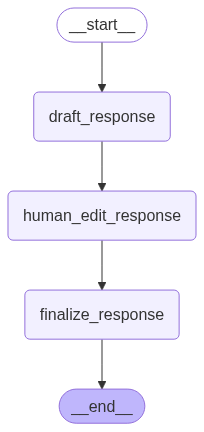

In [23]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
config = {"configurable": {"thread_id": uuid.uuid4()}}
result = graph.invoke({}, config=config)

print(result["__interrupt__"])

[Interrupt(value={'task': 'Please review and edit the customer response if necessary.', 'current_response': 'Thank you for your message. Your issue has been received and will be reviewed shortly.'}, resumable=True, ns=['human_edit_response:87a84b01-f0cc-8cf4-f011-caa431b8c1e0'])]


In [25]:
revised_text = "Thank you for contacting support. We are reviewing your issue and will follow up shortly."

In [26]:
resumed = graph.invoke(
    Command(resume={"revised_response": revised_text}),
    config=config
)
print(resumed)

{'customer_response': 'Thank you for contacting support. We are reviewing your issue and will follow up shortly.'}
